# Tratando os dados de internações

Este notebook consolida as **internações por doenças respiratórias** (SUS) no **município do Rio de Janeiro** e prepara a **série diária de internações** para modelagem.
O foco é: leitura dos dados brutos anuais, filtros clínicos e geográficos coerentes com exposição ambiental e uma **análise exploratória inicial**.

> **Escopo**: 2012–2025, diagnósticos respiratórios (CID-10 selecionados), residentes da cidade do Rio e permanência hospitalar > 0.

## Objetivos desta etapa
1. **Carregar** todos os parquet anuais (2012–2025) diretamente do GitHub (*raw*).
2. **Padronizar** campos-chave (datas, CID-10) e **filtrar** registros de interesse.
3. **Construir** a série **diária** de internações (`data_dia` × `internacoes`).

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import linregress
import matplotlib.dates as mdates

## Carregamento e Unificação dos dados do SUS

In [3]:
anos = range(2012, 2022)
tpl = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_{ano}.parquet"

dfs = []
for ano in anos:
    url = tpl.format(ano=ano)
    print(f"Lendo: {url}")
    df = pd.read_parquet(url)
    dfs.append(df)

df_sus = pd.concat(dfs, ignore_index=True)

Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2012.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2013.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2014.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2015.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2016.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/RawData/DataSus/dados_filtrados_2017.parquet
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/h

## Inspeção inicial

Visão geral de dimensões, tipos, amostra e dados ausentes. A coluna de data principal
virá de `DT_INTER` (quando numérica tipo `YYYYMMDD`) ou de `data_formatada` (se já estiver disponível).

In [4]:
print("Dimensões:", df_sus.shape)

print("\nTipos:")
print(df_sus.dtypes)

print("\nAmostra:")
display(df_sus.head(5))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_sus.isna().sum().sort_values(ascending=False)
na_perc   = (df_sus.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (3005207, 15)

Tipos:
MUNIC_RES         string[python]
NASC              string[python]
SEXO                       Int64
DT_INTER          string[python]
DT_SAIDA          string[python]
DIAG_PRINC        string[python]
DIAG_SECUN        string[python]
IDADE             string[python]
COD_IDADE         string[python]
RACA_COR          string[python]
ETNIA             string[python]
DIAS_PERM         string[python]
MORTE             string[python]
CID_MORTE         string[python]
data_formatada            object
dtype: object

Amostra:


,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada
0,330490,20051114,3,20120101,20120103,J459,,6,4,03,0000,2,0,,2012-01-01
1,330490,20080316,1,20120101,20120103,J40,,3,4,01,0000,2,0,,2012-01-01
2,330250,19310415,3,20120101,20120110,J188,,80,4,99,0000,9,1,J188,2012-01-01
3,330380,19760511,3,20120101,20120104,J219,,35,4,99,0000,3,0,,2012-01-01
4,330490,20110605,3,20120101,20120104,J189,,6,3,01,0000,3,0,,2012-01-01



Valores ausentes por coluna (top 20):


,NA_count,NA_%
MUNIC_RES,0,0.0
NASC,0,0.0
SEXO,0,0.0
DT_INTER,0,0.0
DT_SAIDA,0,0.0
DIAG_PRINC,0,0.0
DIAG_SECUN,0,0.0
IDADE,0,0.0
COD_IDADE,0,0.0
RACA_COR,0,0.0


## Filtrando dados de saúde

### Filtrando por CID-10 de Interesse

Nesta etapa, serão filtrados os códigos CID-10 relevantes para nossa análise:

**Códigos selecionados:**
- **Pneumonia:** J18, J15
- **Insuficiência Respiratória:** J21, J96  
- **Bronquites:** J40, J41, J42
- **Enfisema/DPOC:** J43, J44
- **Asma:** J45, J46

In [5]:
cids_associados_a_poluicao = {"J15","J18","J21","J96","J40","J41","J42","J43","J44","J45","J46"}

# Limpando a coluna DIAG_PRINC: convertendo para string, maiúsculas, removendo espaços e caracteres não alfanuméricos
df_sus["DIAG_PRINC"] = (df_sus["DIAG_PRINC"].astype(str).str.upper().str.strip().str.replace(r"[^A-Z0-9]", "",regex=True))

# Extraindo os primeiros 3 caracteres como prefixo CID
df_sus["CID_PREFIXO"] = df_sus["DIAG_PRINC"].str[:3]

# Filtrando o dataframe para incluir apenas linhas com prefixos CID relevantes
sus_filtrado = df_sus[df_sus["CID_PREFIXO"].isin(cids_associados_a_poluicao)].copy()

print(f"Filtered data shape: {sus_filtrado.shape}")
print("\nCID prefix counts:")
print(sus_filtrado["CID_PREFIXO"].value_counts())
print("\nFirst 5 rows of filtered data:")
display(sus_filtrado.head())

Filtered data shape: (2247455, 16)

CID prefix counts:
CID_PREFIXO
J18    912452
J15    575574
J45    160422
J21    158930
J96    145167
J44    137237
J40     72779
J46     34505
J43     27994
J41     17232
J42      5163
Name: count, dtype: int64

First 5 rows of filtered data:


,MUNIC_RES,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,CID_PREFIXO
0,330490,20051114,3,20120101,20120103,J459,,6,4,03,0000,2,0,,2012-01-01,J45
1,330490,20080316,1,20120101,20120103,J40,,3,4,01,0000,2,0,,2012-01-01,J40
2,330250,19310415,3,20120101,20120110,J188,,80,4,99,0000,9,1,J188,2012-01-01,J18
3,330380,19760511,3,20120101,20120104,J219,,35,4,99,0000,3,0,,2012-01-01,J21
4,330490,20110605,3,20120101,20120104,J189,,6,3,01,0000,3,0,,2012-01-01,J18


### Filtrando por Municípios de Interesse

Nesta etapa, serão filtrados os municípios relevantes para nossa análise:

#### Municípios Selecionados

- **330455** - Rio de Janeiro
- **330510** - São João de Meriti
- **330320** - Nilópolis
- **330285** - Mesquita
- **330045** - Belford Roxo
- **330350** - Nova Iguaçu
- **330170** - Duque de Caxias

In [6]:
municipios_interesse = ['330455','330510','330320','330285','330045','330350','330170']

sus_filtrado = sus_filtrado[sus_filtrado['MUNIC_RES'].isin(municipios_interesse)]

print("Dimensões após filtro por municípios:", sus_filtrado.shape)

Dimensões após filtro por municípios: (836837, 16)


### Filtrando por dias de permanência maior que zero

In [7]:
sus_filtrado['DIAS_PERM'] = pd.to_numeric(sus_filtrado['DIAS_PERM'], errors='coerce')

sus_filtrado = sus_filtrado[sus_filtrado['DIAS_PERM'] > 0]

print("Dimensões após filtro por permanência:", sus_filtrado.shape)

Dimensões após filtro por permanência: (823132, 16)



## Série diária de internações


### Corrigindo data

In [8]:
sus_filtrado["data_dia"] = pd.to_datetime(sus_filtrado["data_formatada"], errors="coerce").dt.normalize()

sus_filtrado = sus_filtrado.dropna(subset=["data_dia"])

### Gerando quantidade de internações por dia

In [9]:
internacoes_diario = (
    sus_filtrado.groupby("data_dia")
    .size()
    .rename("num_internacoes")
    .astype("int64")
    .reset_index()
    .sort_values("data_dia")
)

### Preenchendo calendário
Preencher calendário (datas faltantes -> 0 internações)

In [10]:
idx_full = pd.date_range(internacoes_diario["data_dia"].min(),
                        internacoes_diario["data_dia"].max(),
                        freq="D")

internacoes_rj = (
    internacoes_diario.set_index("data_dia")
    .reindex(idx_full, fill_value=0)
    .rename_axis("data_dia")
    .reset_index()
)

### Gerando CSV de saída

In [11]:
project_root = Path().resolve().parents[2]
output_dir = project_root / "Data" / "IntermediaryData" / "DataSus"
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "respiratory_hospitalization_time_series.csv"
internacoes_rj.to_csv(output_csv_path, index=False, encoding="utf-8")

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\DataSus\respiratory_hospitalization_time_series.csv


### Série temporal de internações

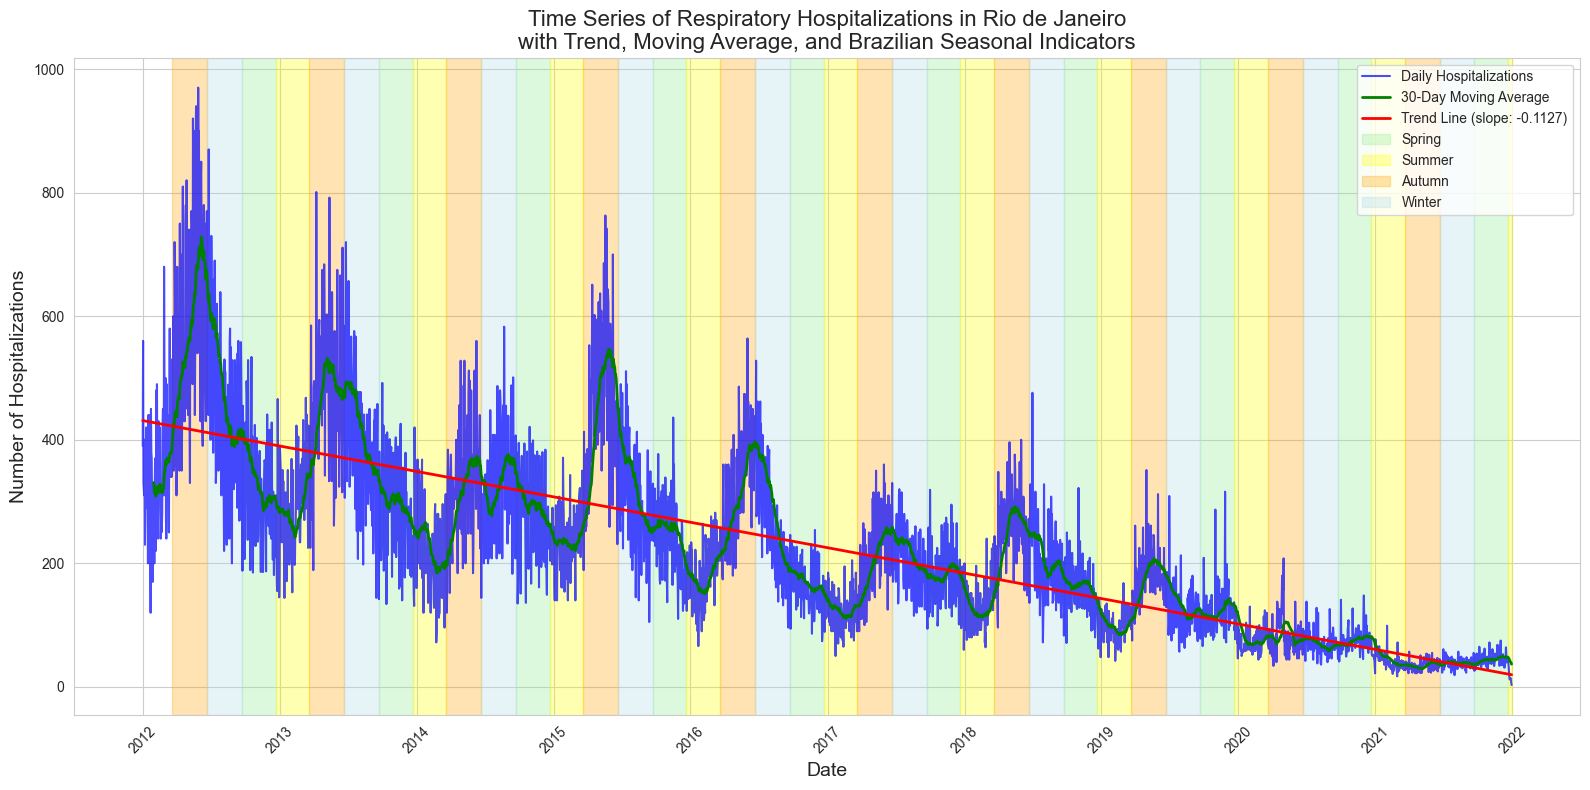

In [12]:
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Série temporal de hospitalizações diárias
plt.plot(internacoes_rj['data_dia'], internacoes_rj['num_internacoes'], linewidth=1.5, color='blue', alpha=0.7, label='Daily Hospitalizations')

# Média móvel de 30 dias
internacoes_rj['moving_avg_30'] = internacoes_rj['num_internacoes'].rolling(window=30).mean()
plt.plot(internacoes_rj['data_dia'], internacoes_rj['moving_avg_30'], linewidth=2, color='green', label='30-Day Moving Average')

# Calcula a tendência linear (slope) e plota a linha de tendência
x_numeric = (internacoes_rj['data_dia'] - internacoes_rj['data_dia'].min()).dt.days
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, internacoes_rj['num_internacoes'])
trend_line = slope * x_numeric + intercept
plt.plot(internacoes_rj['data_dia'], trend_line, color='red', linewidth=2, label=f'Trend Line (slope: {slope:.4f})')

# Adicionar indicadores sazonais brasileiros (estações do ano)
start_date = internacoes_rj['data_dia'].min()
end_date = internacoes_rj['data_dia'].max()

# Datas das estações do ano
def get_season_periods(year):
    return [
        ('Spring', pd.Timestamp(year=year, month=9, day=22), pd.Timestamp(year=year, month=12, day=21)),
        ('Summer', pd.Timestamp(year=year, month=12, day=21), pd.Timestamp(year=year+1, month=3, day=20)),
        ('Autumn', pd.Timestamp(year=year, month=3, day=20), pd.Timestamp(year=year, month=6, day=21)),
        ('Winter', pd.Timestamp(year=year, month=6, day=21), pd.Timestamp(year=year, month=9, day=22))
    ]

season_colors = {
    'Spring': ('lightgreen', 0.3),
    'Summer': ('yellow', 0.3),
    'Autumn': ('orange', 0.3),
    'Winter': ('lightblue', 0.3)
}

for year in range(start_date.year, end_date.year + 1):
    season_periods = get_season_periods(year)
    for season_name, season_start, season_end in season_periods:
        # Adjust for data range
        actual_start = max(season_start, start_date)
        actual_end = min(season_end, end_date)
        if actual_start < actual_end:
            color, alpha = season_colors[season_name]
            plt.axvspan(actual_start, actual_end, color=color, alpha=alpha, label=season_name if year == start_date.year else "")

plt.title('Time Series of Respiratory Hospitalizations in Rio de Janeiro\nwith Trend, Moving Average, and Brazilian Seasonal Indicators', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Hospitalizations', fontsize=14)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()